<a href="https://colab.research.google.com/github/Annet-Maria/Credit-Card-Default-Prediction/blob/main/UCI_Credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install necessary packages for advanced modeling and explainability
!pip install shap xgboost imbalanced-learn xlrd gdown

# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning and Evaluation libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
import shap

# Suppress warnings for a cleaner output
warnings.filterwarnings('ignore')

# Set plotting style for professional-looking academic charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

print("\nLibraries imported successfully!")


Libraries imported successfully!


In [ ]:
# The specific File ID extracted from Google Drive link
file_id = '1CmQzf2tFGE45cRDbYAxMDIpHGGuBDUJb'
url = f'https://drive.google.com/uc?id={file_id}'

# Download the file directly to the Colab environment using gdown
!gdown {url} -O UCI_Credit_Card.xls

# Load the Excel file, skipping the first placeholder row (header=1)
df = pd.read_excel('UCI_Credit_Card.xls', header=1)

# Drop the redundant 'ID' column as it has no predictive value
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

# Rename the target column to something simple for coding
df = df.rename(columns={'default payment next month': 'default'})

print(f"\nDataset Shape: {df.shape}")
print("First 5 rows of the cleaned dataset:")
display(df.head())

Downloading...
From: https://drive.google.com/uc?id=1CmQzf2tFGE45cRDbYAxMDIpHGGuBDUJb
To: /content/UCI_Credit_Card.xls
100% 5.54M/5.54M [00:00<00:00, 205MB/s]

Dataset Shape: (30000, 24)
First 5 rows of the cleaned dataset:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Correlations for examining

1. Credit limit vs bill amounts

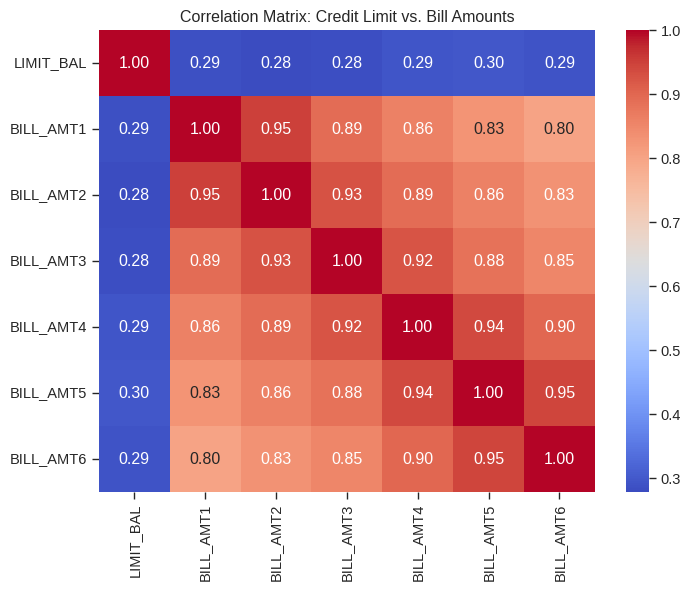

Correlations of Credit Limit with Bill Amounts:
BILL_AMT1    0.285430
BILL_AMT2    0.278314
BILL_AMT3    0.283236
BILL_AMT4    0.293988
BILL_AMT5    0.295562
BILL_AMT6    0.290389
Name: LIMIT_BAL, dtype: float64


In [ ]:
columns_to_correlate = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

correlation_matrix = df[columns_to_correlate].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Credit Limit vs. Bill Amounts')
plt.show()

print("Correlations of Credit Limit with Bill Amounts:")
print(correlation_matrix['LIMIT_BAL'].drop('LIMIT_BAL'))

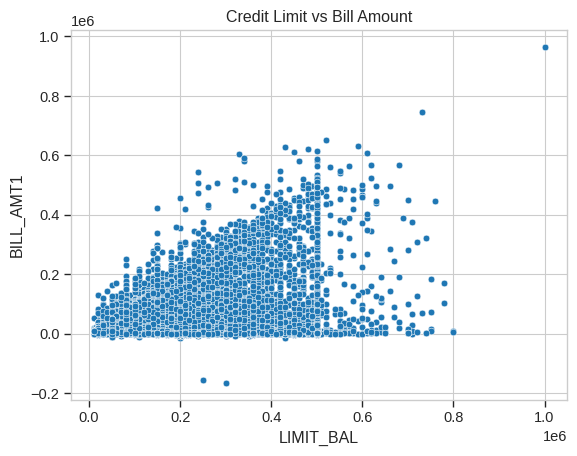

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='LIMIT_BAL', y='BILL_AMT1')
plt.title('Credit Limit vs Bill Amount')
plt.show()

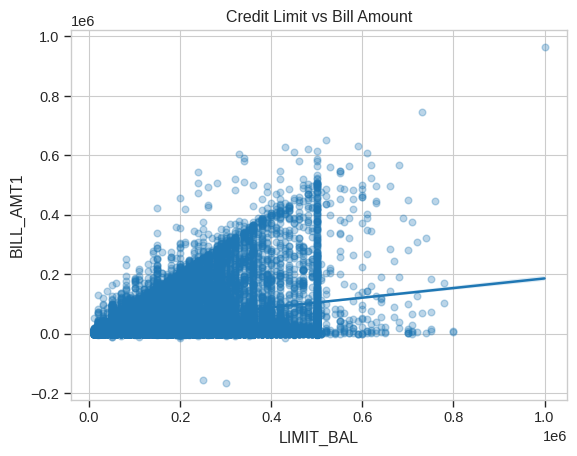

In [ ]:
sns.regplot(data=df, x='LIMIT_BAL', y='BILL_AMT1', scatter_kws={'alpha':0.3})
plt.title('Credit Limit vs Bill Amount')
plt.show()

2. Repayment status vs default

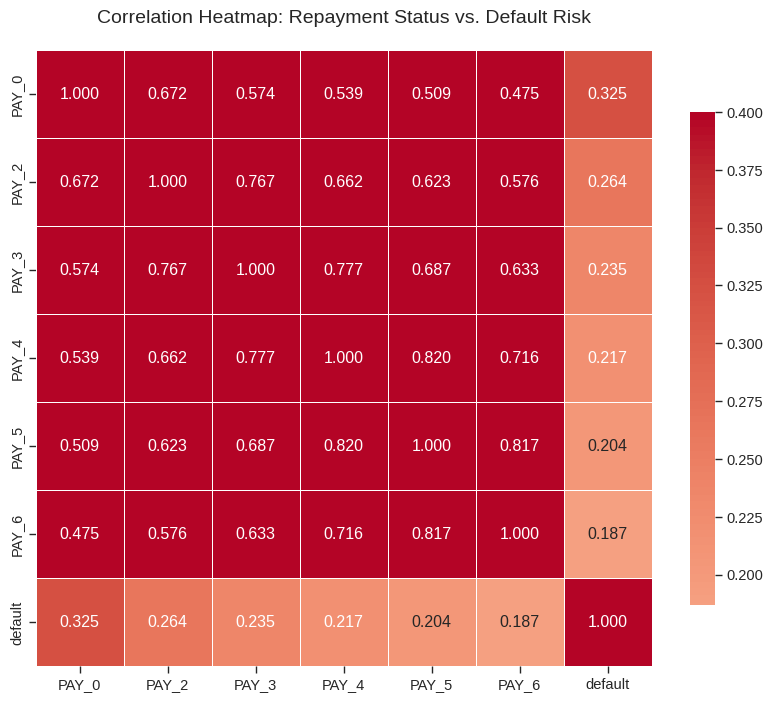

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the specific columns we want to isolate
# PAY_0 to PAY_6 represent the repayment status over the last 6 months
repayment_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default']

# 2. Filter the dataframe and calculate the correlation matrix
repayment_corr = df[repayment_cols].corr()

# 3. Create the targeted heatmap
plt.figure(figsize=(10, 8))

# We use annot=True here to show the exact correlation numbers for the paper
sns.heatmap(repayment_corr,
            annot=True,          # Show the exact correlation values
            fmt=".3f",           # Format to 3 decimal places
            cmap='coolwarm',     # Red for positive correlation, blue for negative
            vmax=0.4,            # Cap the color scale to make the default correlations pop
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Repayment Status vs. Default Risk', pad=20, fontsize=14)
plt.show()

3. Bill amount vs repayment amount

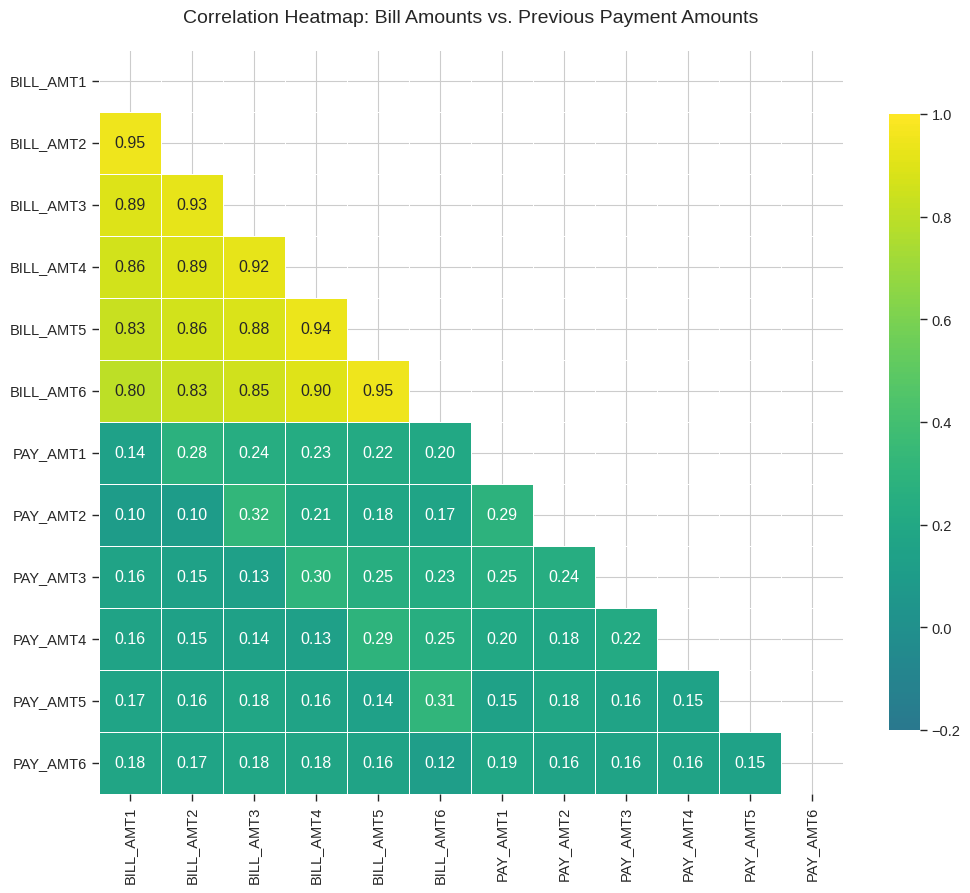

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the specific columns for Bill Amounts and Repayment Amounts
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Combine the lists to filter the dataframe
combined_cols = bill_cols + pay_amt_cols

# 2. Filter the dataframe and calculate the correlation matrix
liquidity_corr = df[combined_cols].corr()

# 3. Create the targeted heatmap
plt.figure(figsize=(12, 10))

# Generate a mask for the upper triangle so we don't show duplicate information
import numpy as np
mask = np.triu(np.ones_like(liquidity_corr, dtype=bool))

sns.heatmap(liquidity_corr,
            mask=mask,
            annot=True,          # Show exact correlation numbers
            fmt=".2f",           # Format to 2 decimal places to keep it clean
            cmap='viridis',      # Using a different color palette to distinguish from the previous chart
            vmax=1.0,
            vmin=-0.2,
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Bill Amounts vs. Previous Payment Amounts', pad=20, fontsize=14)
plt.show()

4. Temporal dependence ( Financial behaviour over months)

    

*   BILL_AMT1 with BILL_AMT2, BILL_AMT3  
*   PAY_0 with PAY_2, PAY_3,

Limit Balance Vs Default

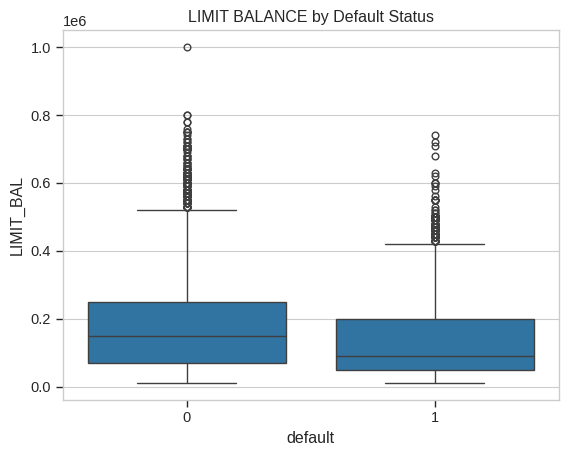

In [ ]:
sns.boxplot(data=df, x='default', y='LIMIT_BAL')
plt.title('LIMIT BALANCE by Default Status')
plt.show()

Defaulters often cluster in relatively lower credit-limit groups

Ordinal variable vs binary target

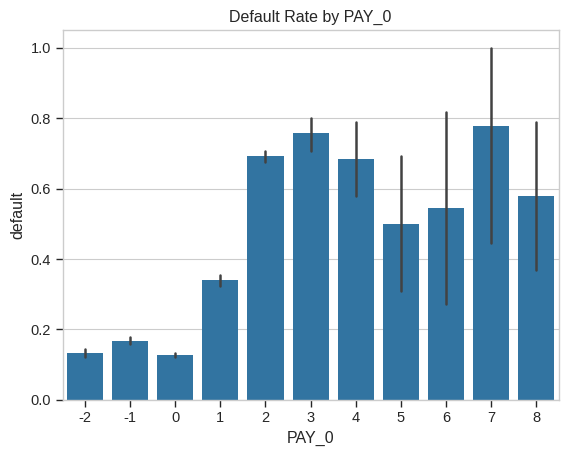

In [ ]:
sns.barplot(data=df, x='PAY_0', y='default')
plt.title('Default Rate by PAY_0')
plt.show()

As recent repayment delay increases, default probability rises sharply.

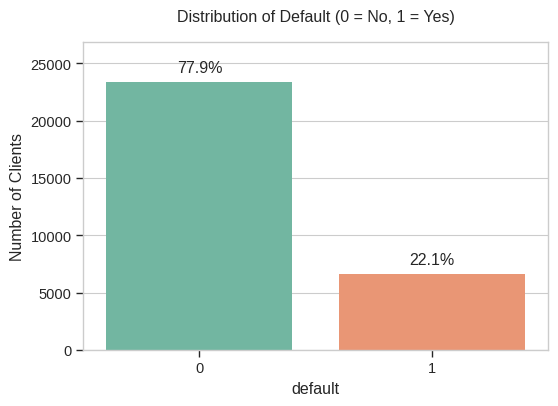

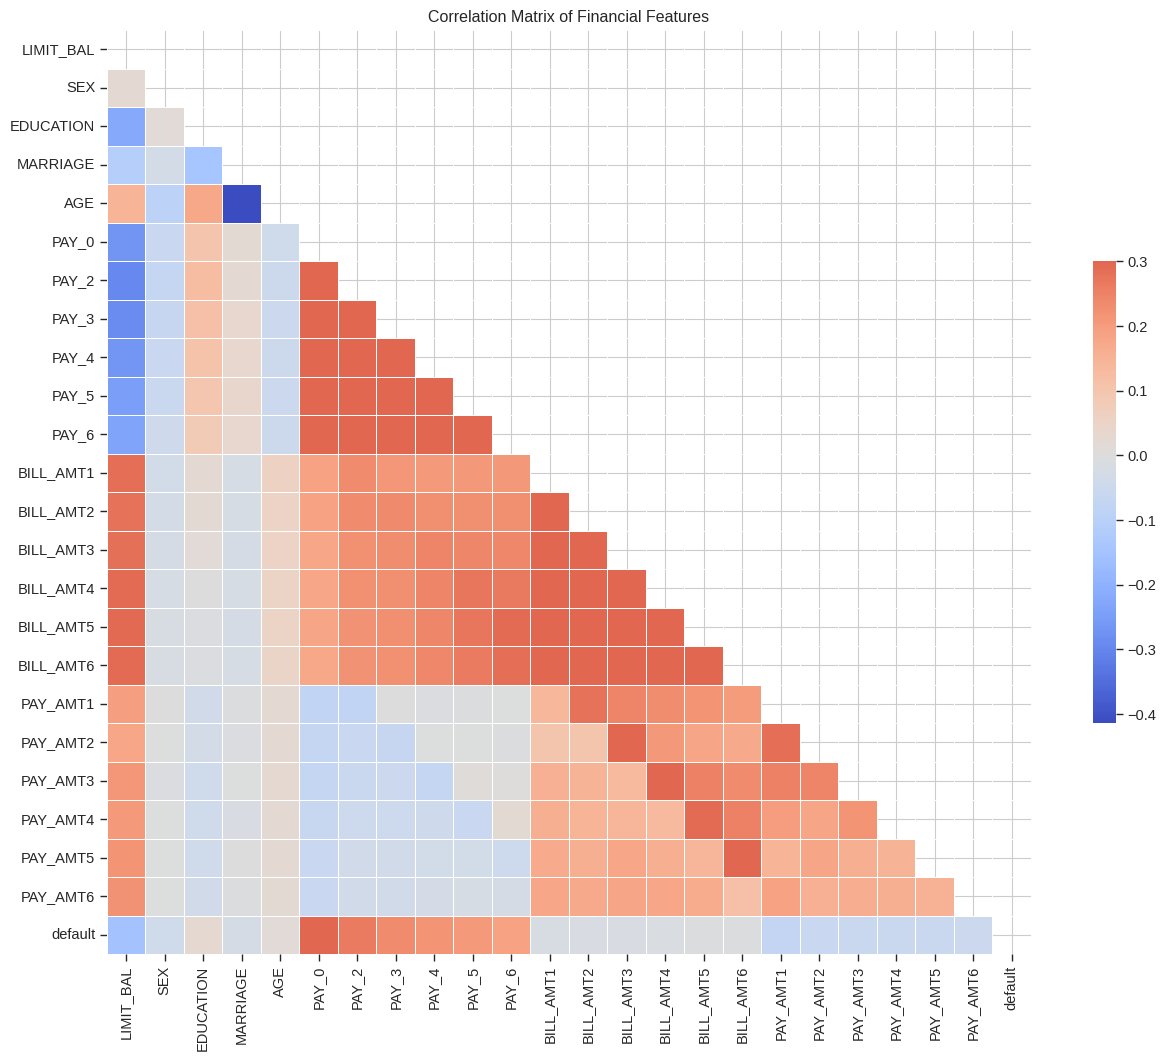

In [ ]:
# 1. Visualize Class Imbalance
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='default', data=df, palette='Set2')

# Dynamically increase the y-axis limit to create "headroom" for the text
max_height = max([p.get_height() for p in ax.patches])
ax.set_ylim(0, max_height * 1.15)

plt.title('Distribution of Default (0 = No, 1 = Yes)', pad=15)
plt.ylabel('Number of Clients')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    # Use xytext to add exactly 5 points of padding above the bar
    ax.annotate(percentage, (x, y), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
plt.show()

# 2. Visualize Feature Correlations
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix of Financial Features')
plt.show()

In [ ]:
# Separate features (X) and target (y)
X = df.drop('default', axis=1)
y = df['default']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features (Important for models calculating distances)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Apply SMOTE to training data to handle the imbalance of defaulters
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training target distribution:\n{y_train.value_counts()}")
print(f"\nResampled training target distribution (after SMOTE):\n{y_train_smote.value_counts()}")

Original training target distribution:
default
0    18691
1     5309
Name: count, dtype: int64

Resampled training target distribution (after SMOTE):
default
0    18691
1    18691
Name: count, dtype: int64


--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.87      0.68      0.77      4673
           1       0.36      0.63      0.46      1327

    accuracy                           0.67      6000
   macro avg       0.61      0.66      0.61      6000
weighted avg       0.75      0.67      0.70      6000

ROC-AUC: 0.7104

--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4673
           1       0.57      0.43      0.49      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.67      0.68      6000
weighted avg       0.79      0.80      0.79      6000

ROC-AUC: 0.7502



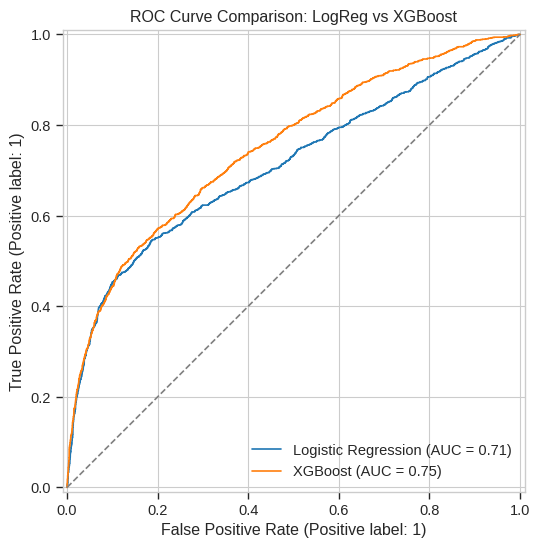

In [ ]:
# 1. Train Traditional Baseline (Logistic Regression)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_log = log_reg.predict(X_test_scaled)

# 2. Train Advanced Ensemble (XGBoost)
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Print Metrics
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log):.4f}\n")

print("--- XGBoost Performance ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}\n")

# Plot ROC Curves
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(log_reg, X_test_scaled, y_test, name='Logistic Regression', ax=plt.gca())
RocCurveDisplay.from_estimator(xgb_model, X_test_scaled, y_test, name='XGBoost', ax=plt.gca())
plt.title('ROC Curve Comparison: LogReg vs XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.show()

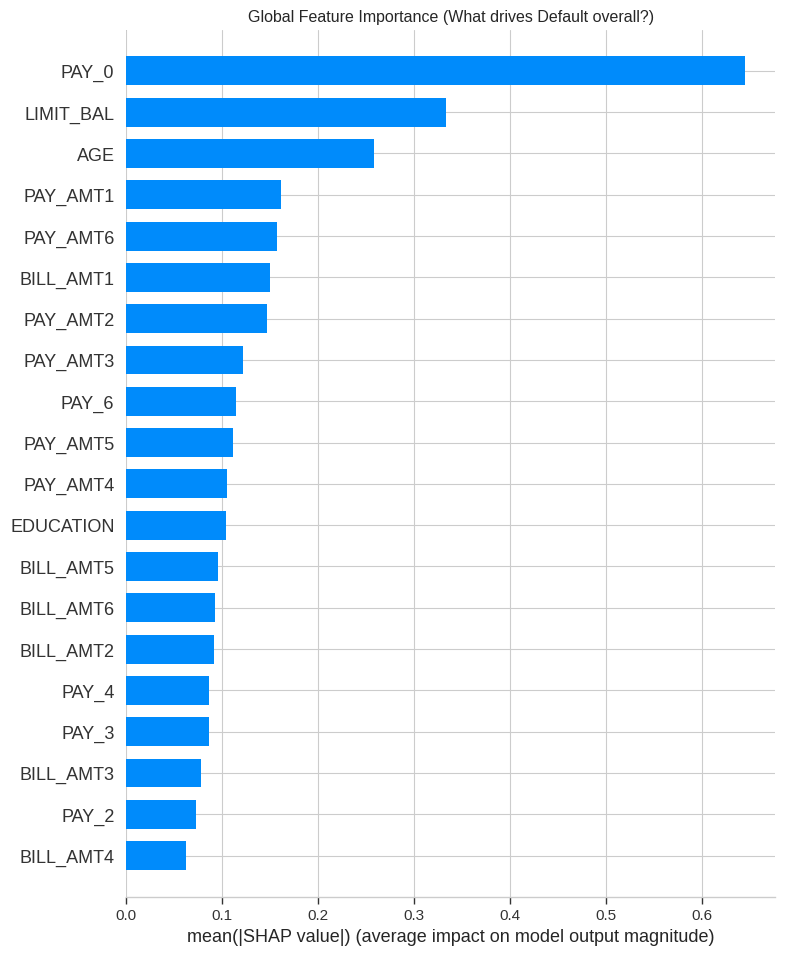

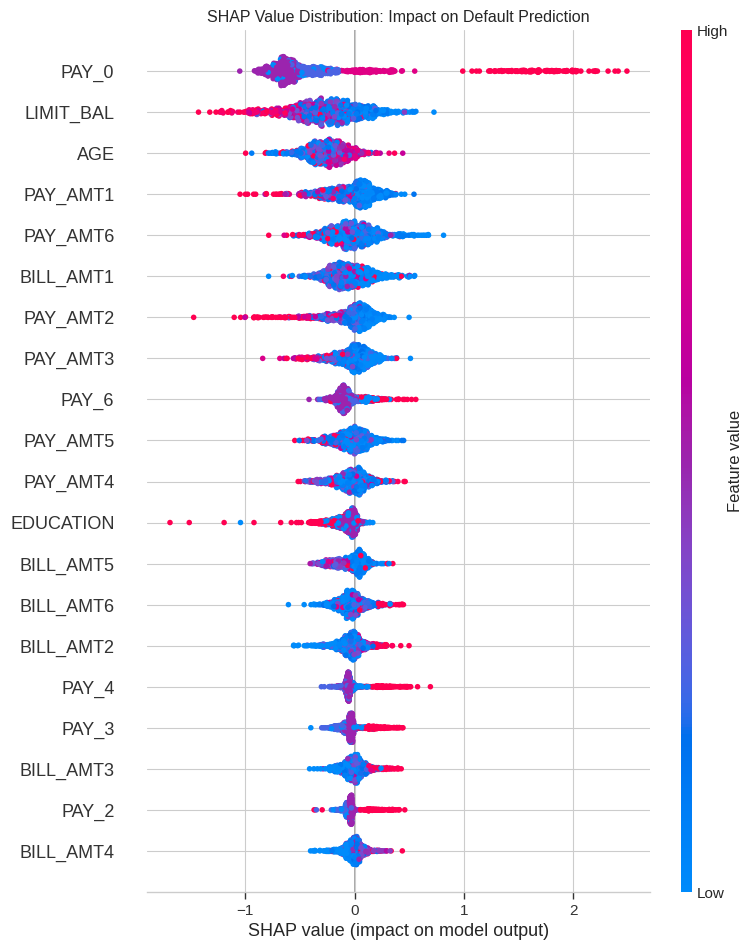

In [ ]:
# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Use a sample of 1000 from the test set to prevent Colab RAM crashes during visualization
X_test_sample = X_test_scaled.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 1. Global Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title('Global Feature Importance (What drives Default overall?)')
plt.show()

# 2. Detailed SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Value Distribution: Impact on Default Prediction')
plt.show()